In [ ]:
Content
1. All Databases
2. Database Internals

# 1. All Databases

In [ ]:
Type                     | Schema         | Data Model            | Examples                          | Best Use Case
-------------------------|----------------|-----------------------|------------------------------------|-----------------------------------------
Relational (RDBMS)       | Fixed          | Tables (rows/columns) | MySQL, PostgreSQL, SQL Server      | Transactions, data integrity
Document-Based (NoSQL)   | Flexible       | JSON/BSON/XML docs    | MongoDB, CouchDB                   | Catalogs, CMS, user profiles
Key-Value (NoSQL)        | None           | Key-value pairs       | Redis, DynamoDB                    | Caching, sessions
Column-Family (NoSQL)    | Flexible       | Column groups         | Cassandra, HBase                   | Analytics, time-series
Graph (NoSQL)            | Flexible       | Nodes & edges         | Neo4j, Amazon Neptune              | Social networks, recommendations
In-Memory                | None/Flexible  | Various               | Redis, Memcached                   | Real-time apps, caching
Time-Series              | Flexible       | Time-stamped data     | InfluxDB, TimescaleDB              | IoT, monitoring, metrics
Object Storage           | None           | Binary + metadata     | Amazon S3, Azure Blob              | Media files, backups
NewSQL                   | Fixed          | Tables                | Google Spanner, CockroachDB        | Scalable SQL workloads
Multi-Model              | Flexible       | Multiple models       | ArangoDB, OrientDB                 | Flexible apps with diverse data types
Search Engine DB         | Flexible       | Inverted index        | Elasticsearch, Solr                | Search & analytics

In [ ]:
1. Relational Databases (RDBMS)
	•	Definition: Store data in tables with rows & columns.
	•	Schema: Fixed (predefined).
	•	Query Language: SQL.
	•	Strengths: ACID transactions, strong consistency, complex joins.
	•	Examples: MySQL, PostgreSQL, SQL Server, Oracle.
	•	Use Case: Banking, ERP, e-commerce — where data relationships & ACID are crucial.

2. NoSQL Databases
    2.1 Document-Based
    	•	Stores JSON/BSON/XML documents.
    	•	Flexible schema.
    	•	Example: MongoDB, CouchDB.
    	•	Use Case: Content management, catalogs.

    2.2 Key-Value Stores
    	•	Data stored as simple key-value pairs.
    	•	Extremely fast lookups.
    	•	Example: Redis, DynamoDB (key-value mode).
    	•	Use Case: Caching, session storage.  

    2.3 Column-Family Stores
    	•	Store data in columns rather than rows (good for aggregation).
    	•	Example: Apache Cassandra, HBase.
    	•	Use Case: Analytics, time-series.

    2.4 Graph Databases
    	•	Data stored as nodes and edges (relationships).
    	•	Example: Neo4j, Amazon Neptune.
    	•	Use Case: Social networks, recommendation engines.        

3. In-Memory Databases
	•	Store data entirely in RAM for ultra-low latency.
	•	Example: Redis, Memcached.
	•	Use Case: Caching, gaming leaderboards, real-time analytics.

4. Time-Series Databases
	•	Optimized for storing and querying time-stamped data.
	•	Example: InfluxDB, TimescaleDB.
	•	Use Case: IoT data, monitoring metrics.

5. Object Storage-Based Databases
	•	Store binary objects with metadata.
	•	Example: Amazon S3, Azure Blob.
	•	Use Case: Media files, backups.

6. NewSQL Databases
	•	Relational model but designed for horizontal scalability.
	•	Example: Google Spanner, CockroachDB.
	•	Use Case: Large-scale applications needing SQL & scalability.

7. Multi-Model Databases
	•	Support multiple data models (document, graph, key-value) in one engine.
	•	Example: ArangoDB, OrientDB.
	•	Use Case: Applications needing flexibility in data representation.

8. Search Engines as Databases
	•	Optimized for text search & analytics.
	•	Example: Elasticsearch, Solr.
	•	Use Case: Full-text search, log analytics.        

# 2. Database Internals

In [ ]:
# Database Internals
1. Frontend: API data format
2. Storage Engine: Storage Index, data files, Transactions, WAT



# 3. NoSQL/ MongoDB

In [ ]:
- MongoDB is a document-oriented NoSQL database that stores data in BSON (binary JSON) format.
- Unlike relational DBs (SQL), there are no fixed schemas (tables, rows, columns).
- Data is grouped into:
	•	Database
	•	Collections (like tables)
	•	Documents (like rows → JSON objects)

# How MongoDB Works Internally
a) Storage Engine
MongoDB uses a storage engine that handles how data is stored on disk:
	•	WiredTiger (default since v3.2)
    	•	Stores data in compressed B-trees.
    	•	Uses document-level locking (instead of collection-level locks → better concurrency).
    	•	Supports journaling for crash recovery.
	•	MMAPv1 (deprecated) → used memory-mapped files.

b) Data Representation
	•	Documents are stored in BSON, which supports:
    	•	JSON-like types (string, int, array, object)
    	•	Extra types like date, binary, ObjectId

c) Query Execution
	1.	Query comes in (e.g. db.users.find({ age: 25 }))
	2.	Query planner checks available indexes.
	3.	Uses the query optimizer to pick best execution plan.
	4.	Traverses indexes → fetches matching documents from disk.
	5.	Returns results as BSON → driver converts to JSON/objects in your language.

# Key Points:
    1. Insertions and Retrievals are done on complete JSON blob
    2. Schema is flexible, and easily changable. adding a new column is sql which is a very expensive operation.
    3. Sharding, built for scale. and more focus on availability.
        - They are eventual Consistent, they might write the data into other nodes in background, which might take some time.
    4. Best for metrics, analytics, and aggregation.


# Cons:
1. Not built for frequent updates.
2. ACID is not guarantee.
3. Read times are slower.
4. Relations are not implicite, ex: No foreign key constraint.
5. Joins are problems.

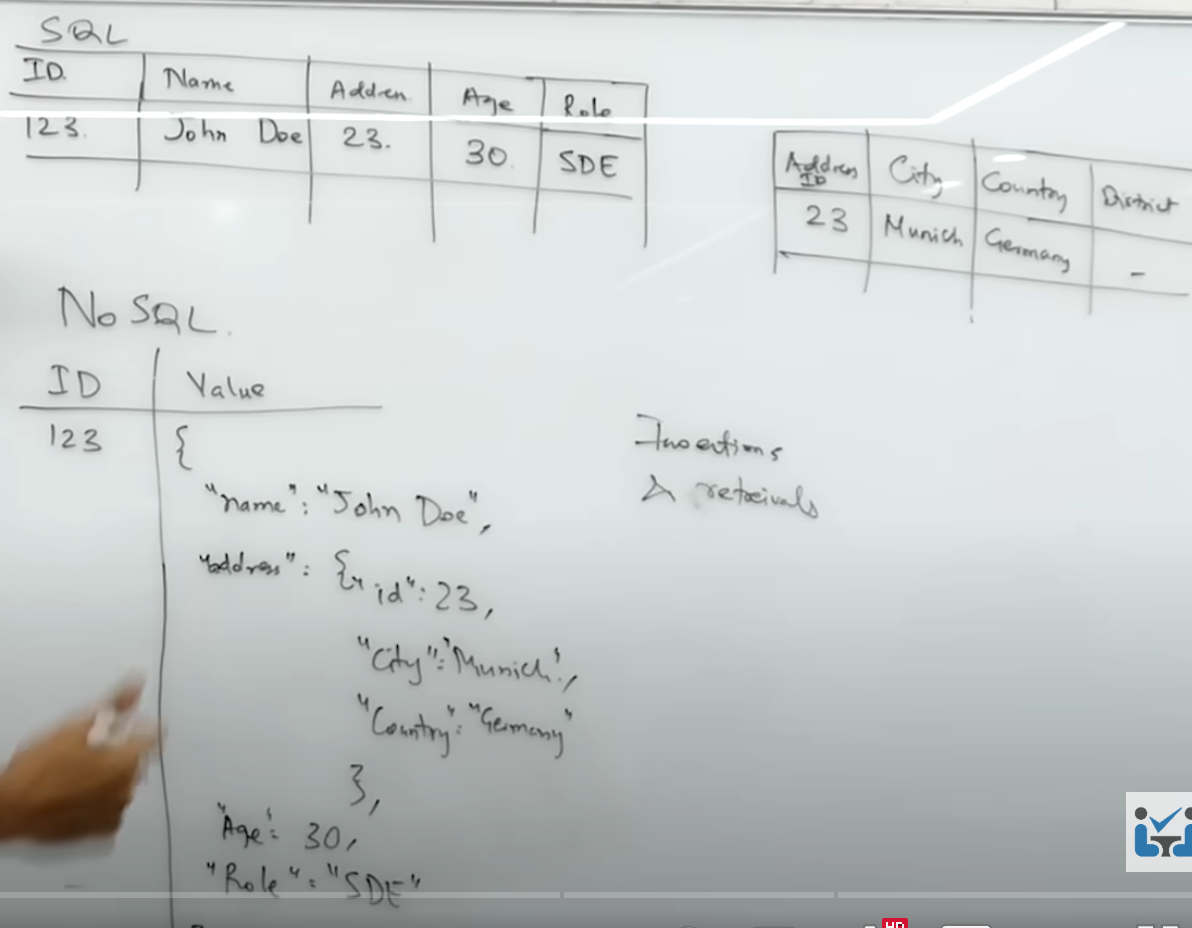

In [ ]:
# JSON vs BJSON
•	JSON = great for interchange between systems (human-friendly).
•	BSON = great for storage & speed inside MongoDB (machine-friendly).
Aspect              | JSON                          | BSON
--------------------|-------------------------------|------------------------------
Format              | Text-based (UTF-8)            | Binary format
Readability         | Human-readable                | Not human-readable
Parsing Speed       | Slower (string parsing)       | Faster (binary decoding)
Data Types          | Limited (string, number...)   | Richer (int, long, date, bin, ObjectId...)
Storage Size        | Larger (verbose)              | More compact (indexes + binary)
Use Case            | APIs, config, web apps        | Database storage, high perf systems


# Differences
SQL (RDBMS)          | MongoDB (NoSQL)
---------------------|--------------------------
Tables               | Collections
Rows                 | Documents (JSON/BSON)
Schema (fixed)       | Schema-less (flexible)
Joins (complex)      | Embedded docs / $lookup
Scaling = vertical   | Scaling = horizontal (sharding)
ACID transactions    | Eventually consistent (now supports multi-doc ACID since v4.0+)

## Indexing

In [ ]:
Indexes are B-tree structures, similar to relational DBs.
•	Types of Indexes:
	•	Single field index: { age: 1 }
	•	Compound index: { age: 1, city: -1 }
	•	Multikey index: for array fields.
	•	Text index: for searching strings.
	•	Geospatial index: for location-based queries.
	•	Hashed index: good for sharding keys.
- All Indexes are doubly link list.
        
# Index  
1. Default _id Index
	•	Every collection must have a unique index on _id.
	•	But: this is not clustered in the SQL sense.
	•	The _id index is a regular B-tree where leaves store _id → RecordId pointer.
	•	Documents themselves live separately in WiredTiger’s data files.

2. Clustered Collections (MongoDB 5.0+)
	•	MongoDB introduced Clustered Collections (similar to clustered index in RDBMS).
	•	In a clustered collection:
    	•	Documents are stored in index order by the clustered key.
    	•	The clustered index’s leaf nodes contain the actual BSON document, not just a pointer.
    	•	Great for time-series, range queries, or monotonically increasing keys.
    	•	You can have only one clustered index per collection (like SQL’s clustered index).

3. non-clustered indexes
	•	All other indexes in MongoDB are non-clustered indexes.
	•	They store key + pointer to the record (RecordId), and need a document fetch unless query is covered.
	•	The full BSON document lives separately in the collection’s data file.
	•	If the query is covered by the index, MongoDB may avoid fetching the full doc.
	•	If the query is covered by the index, MongoDB may avoid fetching the full doc.

        
    •	In a B+ tree (which MongoDB’s WiredTiger uses for indexes), leaf nodes are linked together in a doubly linked list (for both clustered and non-clustered index)
	•	Each leaf node stores:
    	•	Keys (fieldValue → RecordId)
    	•	A pointer to the next leaf
    	•	A pointer to the previous leaf

                 (B+ Tree Index on "id")
                 ┌──────────────┐
                 │ Internal Node│
                 │   [50]       │
                 └─────┬────────┘
             ┌─────────┴─────────┐
             v                   v
       ┌────────────┐       ┌────────────┐
       │  Leaf Node │       │  Leaf Node │
       │ id=10→RID1 │       │ id=60→RID3 │
       │ id=25→RID2 │       │ id=70→RID4 │
       └────────────┘       └────────────┘
              |                    |
              v                    v
     ┌─────────────────┐   ┌─────────────────┐
     │ Collection Data │   │ Collection Data │
     │ RID1 → BSON doc │   │ RID3 → BSON doc │
     │ RID2 → BSON doc │   │ RID4 → BSON doc │
     └─────────────────┘   └─────────────────┘                 


## Scaling

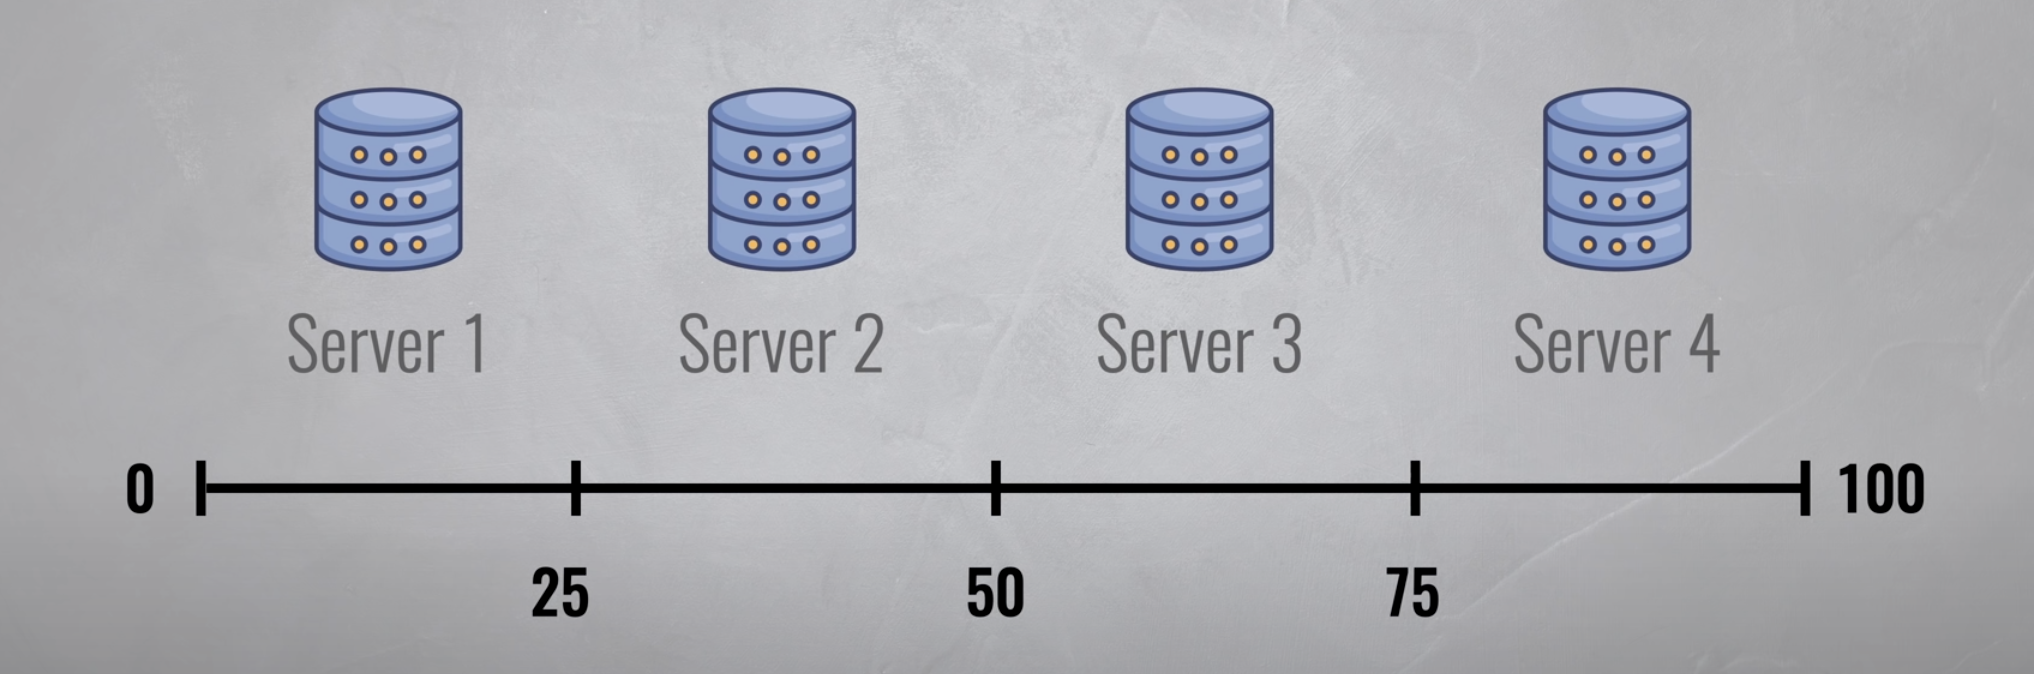

In [ ]:
MongoDB supports horizontal scaling via sharding.
•	Replication:
	•	Replica Set = Primary + Secondary nodes.
	•	Primary handles writes, secondaries replicate asynchronously.
	•	Provides HA (High Availability) & read scaling (reads can go to secondaries).
•	Sharding (Horizontal Partitioning):
	•	Data is split across multiple servers (shards).
	•	Needs a shard key (like userId or regionId).
	•	A mongos router directs queries to correct shard(s).
	•	Balancer moves chunks of data across shards to maintain load balance.
•	Why it scales well:
	•	You can add more machines to handle more data.
	•	Reads and writes get distributed.

1. Sharding
    Shard 1 (Node A) -> Keys 1 to 1000
    Shard 2 (Node B) -> Keys 1001 to 2000
    Shard 3 (Node C) -> Keys 2001 to 3000     

2. Replication (copy of data)
    - Writes always go to the primary.
	- The primary sends updates to its replicas (called replication).
	- Reads can be served by any replica (so you can handle more read requests).
    - This is how read scaling works → traffic is spread across many replicas.

    Shard 1 -> Primary copy (writes go here)
             -> Replica 1 (read-only copy)
             -> Replica 2 (read-only copy)
    
    Shard 2 -> Primary + Replicas
    Shard 3 -> Primary + Replicas        

3. Adding a new node
    1.	Metadata updated (routing info knows there’s a new shard).
	2.	Data rebalancing → Some data from existing nodes is copied/moved to the new node.
    	•	In MongoDB → chunks are migrated.
    	•	In Cassandra → consistent hashing automatically moves ranges of keys.
	3.	From then on, queries for those keys go to the new node.

4. Removing a node
    If a node is removed (failure or scaling down):
    	•	The system detects the node is gone.
    	•	Other nodes that already have replicas of that data are promoted.
    	•	Metadata is updated so traffic avoids the dead node.
    👉 This ensures the database is still available.                                        

5. Example flow: write operation in MongoDB

Let’s say you insert a new user { id: 101, name: "Alice" }.
	1.	Router checks shard key (say shard by id).
→ id=101 belongs to Shard 1.
	2.	Request goes to Shard 1 primary.
	3.	Primary writes data to its storage engine.
	4.	Primary sends the write to its replicas.
	5.	Once replicas confirm, write is considered safe.

If later you add a new shard (Shard 4), some ids (say 500–700) may get migrated to Shard 4.

In [2]:
# Why horizontal scaling is difficult in SQL
1) Joins across tables
   - Normalized schemas = cross-entity joins
   - If tables are on different shards, you need data shipping or distributed joins

2) Global constraints
   - Foreign keys, uniqueness across entire table = global indexes/locks
   - Enforcing them requires cross-shard coordination

3) Multi-row / multi-table ACID transactions
   - Two-phase commit (2PC) or distributed consensus → latency & failure complexity

4) Sequences / auto-increment PKs
   - Centralized counters become hotspots (or require careful partitioned sequences)

5) Secondary indexes that must be globally consistent
   - Writes must update indexes on other shards or maintain global ordering

6) Online resharding while preserving constraints
   - Requires careful transactional metadata moves & backfills

## Connecting

In [ ]:
using MongoDB.Driver;

var client = new MongoClient("mongodb://localhost:27017");
var database = client.GetDatabase("testdb");
var collection = database.GetCollection<BsonDocument>("users");

// Insert
await collection.InsertOneAsync(new BsonDocument { { "name", "Sourav" }, { "age", 28 } });

// Query
var filter = Builders<BsonDocument>.Filter.Eq("name", "Sourav");
var result = await collection.Find(filter).FirstOrDefaultAsync();
Console.WriteLine(result);\



# Queries
// Create indexes
db.users.createIndex({ age: 1 });
db.users.createIndex({ age: 1, city: 1 });            // compound
db.users.createIndex({ skills: 1 });                  // multikey if skills is array
db.users.createIndex({ location: "2dsphere" });       // geo
db.users.createIndex({ name: "text" });               // text
db.users.createIndex({ createdAt: 1 }, { expireAfterSeconds: 86400 }); // TTL
db.users.createIndex({ isActive: 1 }, { partialFilterExpression: { isActive: true }});

// Inspect plans
db.users.find({ age: { $gte: 25, $lt: 30 } }).sort({ city: 1 }).explain("executionStats");

// Hint (force index)
db.users.find({ age: 27 }).hint({ age: 1 });